# Computational Carpentry Project

Group: [add group letter]

Team members (replace placeholders before submission):
- [Your full name] — Part A: Data structures and functions
- [Teammate 2 full name] — Part B: Stoichiometry and reaction balancing
- [Teammate 3 full name] — Part C: Simulation / Modeling

Parts B and C are reserved for the other two team members; adjust their assignments if needed.


## Part A — Data structures and functions

### 1. Load the periodic table

We use `pandas.read_csv` to load `periodic_table.csv` into a DataFrame named `periodic_table`. Run the notebook from the repository folder, with the CSV alongside it. The preview shows the column names and the first five elements. Later steps in Part A can reuse the `Symbol` and `AtomicMass` columns.


In [1]:
import pandas as pd

periodic_table = pd.read_csv("periodic_table.csv")
periodic_table.head()


,AtomicNumber,Symbol,Name,AtomicMass,CPKHexColor,ElectronConfiguration,Electronegativity,AtomicRadius,IonizationEnergy,ElectronAffinity,OxidationStates,StandardState,MeltingPoint,BoilingPoint,Density,GroupBlock,YearDiscovered
0,1,H,Hydrogen,1.008000,FFFFFF,1s1,2.20,120.0,13.598,0.754,"+1, -1",Gas,13.81,20.28,0.000090,Nonmetal,1766
1,2,He,Helium,4.002600,D9FFFF,1s2,NaN,140.0,24.587,NaN,0,Gas,0.95,4.22,0.000179,Noble gas,1868
2,3,Li,Lithium,7.000000,CC80FF,[He]2s1,0.98,182.0,5.392,0.618,+1,Solid,453.65,1615.00,0.534000,Alkali metal,1817
3,4,Be,Beryllium,9.012183,C2FF00,[He]2s2,1.57,153.0,9.323,NaN,+2,Solid,1560.00,2744.00,1.850000,Alkaline earth metal,1798
4,5,B,Boron,10.810000,FFB5B5,[He]2s2 2p1,2.04,192.0,8.298,0.277,+3,Solid,2348.00,4273.00,2.370000,Metalloid,1808


## Part C — Simulation/Modeling

## Part 1 - Monte Carlo pi esimation





Let's play with the randomizer a bit

In [2]:
import numpy as np

In [ ]:
import random

x = random.randint(1,10) # for an integer
x = random.uniform(5, 10) # if we want a random float between two fixed numbers
x = random.random() # if we want a random float [0,1[

random_points = []
for i in range(0, 10000):
    x_float = random.uniform(-1,1)
    y_float = random.uniform(-1,1)
    random_points.append([x_float,y_float])
#print(random_points)
  


It turns out that we can generate the numbers a bit faster with numpy:


In [2]:
random_points = np.random.uniform(
    -1, 
    1, 
    size=(100_000_000, 2)
)

Let's save all the points that are inside a circle in a list

In [ ]:
points_inside = []
for point in random_points:
    if np.linalg.norm(point) <= 1:
        points_inside.append(point)

#print(points_inside)
print(len(points_inside))

7853171


Turns out again that numpy can make it so much faster:

In [3]:
norms = np.linalg.norm(random_points, axis = 1)
points_inside = random_points[norms <= 1]
print(len(points_inside))
print(4*len(points_inside)/len(random_points))

78543589
3.14174356


The probability that a random point in the square lies inside the unit circle is

$$
P=\frac{A_{\text{circle}}}{A_{\text{square}}}
=\frac{\pi}{4}.
$$

Therefore,

$$
\pi \approx 4\frac{N_{\text{inside}}}{N}.
$$
That's exactly where the factor of 4 comes from in the code above


Now let's assemble everything together

In [12]:
def estimate_pi(N):
    random_points = np.random.uniform(-1, 1,size=(N, 2))

    norms = np.linalg.norm(random_points, axis = 1)
    points_inside = random_points[norms <= 1]
    approximation = 4*len(points_inside)/len(random_points)
    #print(f" The pi estimate is: {approximation}")
    return approximation

Now let's plot our pi approximation with growing N

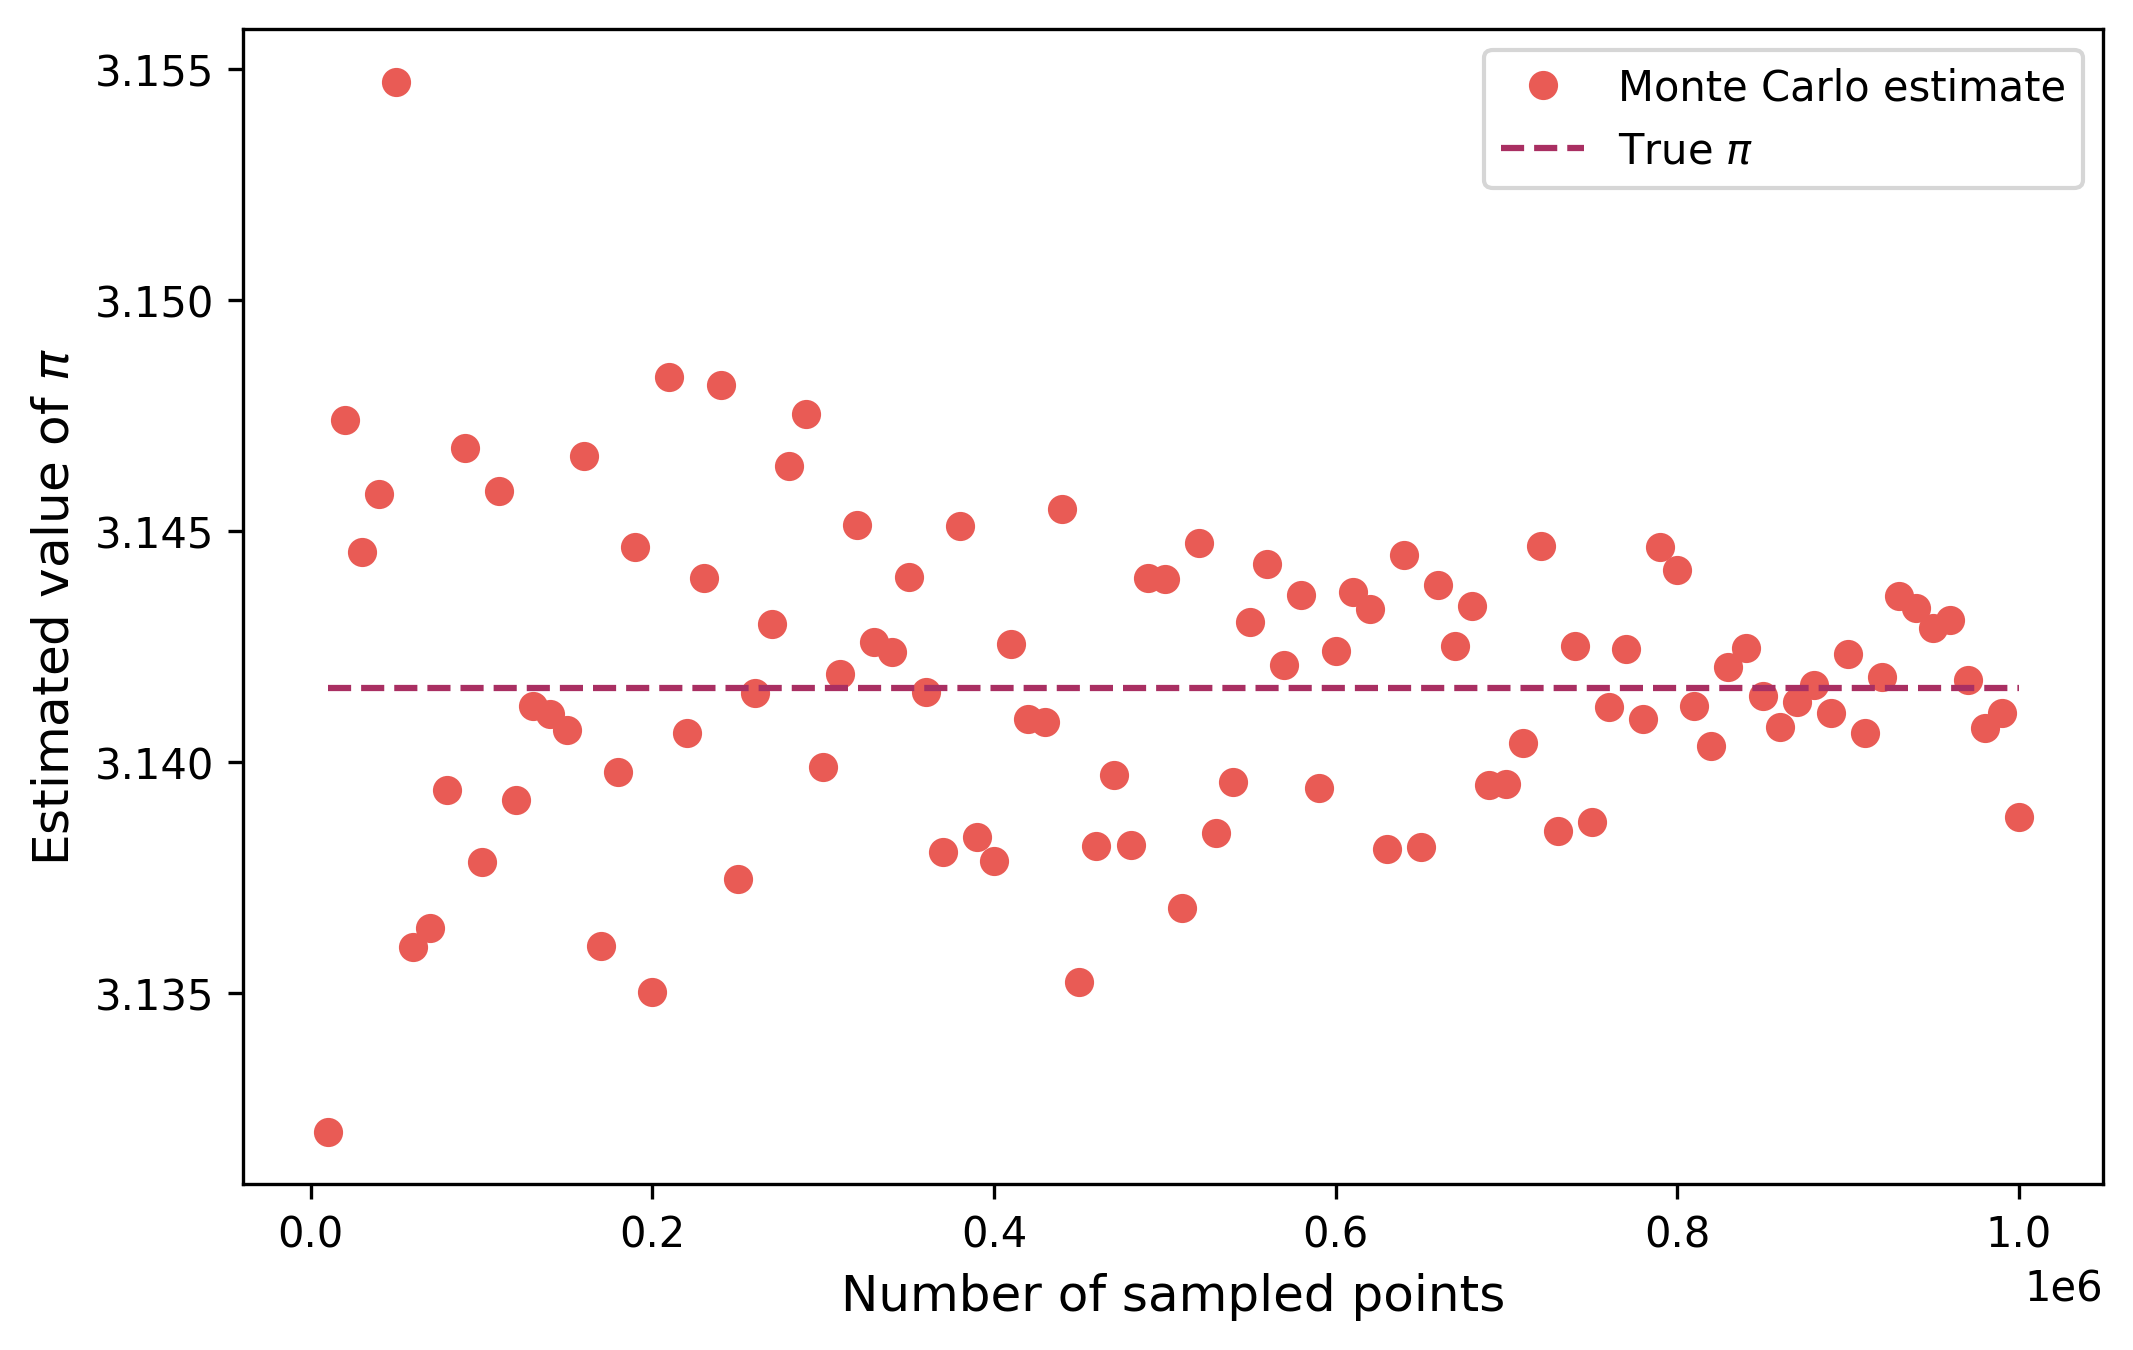

In [62]:
import matplotlib.pyplot as plt

Ns = []
approximations = []

for N in range (10_000, 1_000_001, 10_000): #change to smaller values because it is lowkey long
    approximation = estimate_pi(N)
    Ns.append(N)
    approximations.append(approximation)

plt.figure(figsize=(8, 5), dpi=300) #to have a nice quality

plt.plot(Ns, approximations, linestyle="", marker = "o", color="#E95B55", label="Monte Carlo estimate") # coral, because the default colors are ugly
plt.plot(Ns, [np.pi]*len(Ns), linestyle="--", color="#A92F62",label=r"True $\pi$") # dark magenta

plt.xlabel("Number of sampled points", fontsize=12)
plt.ylabel(r"Estimated value of $\pi$", fontsize=12)
plt.legend()
plt.show()

## Part 2 - Chemistry inspired Monte Carlo


A bit confusing where to start, but let's give it a go by reusing our position randomizer from before


In [ ]:
random_collisions = np.random.uniform(-1, 1, size=(1_000_000, 2))
random_energies = np.random.uniform(0,100,size=1_000_000) #same principle here
#we also have to make sure that arrays have the same number of collisions
threshold_energy = 50
threshold = random_energies >= threshold_energy #choosing the energies above the threshold
above_threshold = random_collisions[threshold] #not neccessary per say, but added in case we want to have them 

print(len(above_threshold))
print(len(above_threshold)/len(random_collisions))


499377
0.499377


We assume that a collision leads to a reaction when

$$
E \geq E_{\text{threshold}}.
$$

We can estimate the reaction probability as

$$
P(\text{reaction})
\approx
\frac{N_{\text{above threshold}}}{M}.
$$

Now let's wrap it up into a nice function


In [ ]:
def simulate_collisions(number_of_collisions, energy_min, energy_max, threshold_energy):
    random_collisions = np.random.uniform(-1, 1, size=(number_of_collisions, 2))
    random_energies = np.random.uniform(energy_min,energy_max,size=number_of_collisions)
    energy_above = random_energies >= threshold_energy
    above_threshold = random_collisions[energy_above]

    above = len(above_threshold)
    probability = len(above_threshold)/len(random_collisions)
    return above, probability

simulate_collisions(1_000_000, 0, 1000, 750)


(250483, 0.250483)